Linear Regression Model

In [1]:
#import the relevant libraries for the data processing and machine learning
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (mean_squared_error, r2_score, accuracy_score,
                             confusion_matrix, classification_report)

In [2]:
# Load the dataset for car price
cars = pd.read_csv("Car_price.csv") 

In [3]:
# Explore the first 5 rows of the dataset
cars.head()

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


In [4]:
# View data types and for missing data using info function
cars.info()

<class 'pandas.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   car_ID            205 non-null    int64  
 1   symboling         205 non-null    int64  
 2   CarName           205 non-null    str    
 3   fueltype          205 non-null    str    
 4   aspiration        205 non-null    str    
 5   doornumber        205 non-null    str    
 6   carbody           205 non-null    str    
 7   drivewheel        205 non-null    str    
 8   enginelocation    205 non-null    str    
 9   wheelbase         205 non-null    float64
 10  carlength         205 non-null    float64
 11  carwidth          205 non-null    float64
 12  carheight         205 non-null    float64
 13  curbweight        205 non-null    int64  
 14  enginetype        205 non-null    str    
 15  cylindernumber    205 non-null    str    
 16  enginesize        205 non-null    int64  
 17  fuelsyst

In [5]:
# View the statistics for the dataset with describe function
cars.describe()

,car_ID,symboling,wheelbase,carlength,carwidth,carheight,curbweight,enginesize,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
count,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000
mean,103.000000,0.834146,98.756585,174.049268,65.907805,53.724878,2555.565854,126.907317,3.329756,3.255415,10.142537,104.117073,5125.121951,25.219512,30.751220,13276.710571
std,59.322565,1.245307,6.021776,12.337289,2.145204,2.443522,520.680204,41.642693,0.270844,0.313597,3.972040,39.544167,476.985643,6.542142,6.886443,7988.852332
min,1.000000,-2.000000,86.600000,141.100000,60.300000,47.800000,1488.000000,61.000000,2.540000,2.070000,7.000000,48.000000,4150.000000,13.000000,16.000000,5118.000000
25%,52.000000,0.000000,94.500000,166.300000,64.100000,52.000000,2145.000000,97.000000,3.150000,3.110000,8.600000,70.000000,4800.000000,19.000000,25.000000,7788.000000
50%,103.000000,1.000000,97.000000,173.200000,65.500000,54.100000,2414.000000,120.000000,3.310000,3.290000,9.000000,95.000000,5200.000000,24.000000,30.000000,10295.000000
75%,154.000000,2.000000,102.400000,183.100000,66.900000,55.500000,2935.000000,141.000000,3.580000,3.410000,9.400000,116.000000,5500.000000,30.000000,34.000000,16503.000000
max,205.000000,3.000000,120.900000,208.100000,72.300000,59.800000,4066.000000,326.000000,3.940000,4.170000,23.000000,288.000000,6600.000000,49.000000,54.000000,45400.000000


In [6]:
# using a unique function to find out the unique values of car names
cars.CarName.unique()

<StringArray>
[      'alfa-romero giulia',      'alfa-romero stelvio',
 'alfa-romero Quadrifoglio',              'audi 100 ls',
               'audi 100ls',                 'audi fox',
                'audi 5000',                'audi 4000',
      'audi 5000s (diesel)',                 'bmw 320i',
 ...
                'vw rabbit',        'volkswagen rabbit',
 'volkswagen rabbit custom',          'volvo 145e (sw)',
              'volvo 144ea',              'volvo 244dl',
                'volvo 245',              'volvo 264gl',
             'volvo diesel',                'volvo 246']
Length: 147, dtype: str

In [7]:
# Replace the column horsepower missing values with mean
# (assignment form used instead of inplace=True on a column, which is a no-op under pandas copy-on-write)
cars['horsepower'] = cars['horsepower'].replace('?', np.nan)
cars['horsepower'] = cars['horsepower'].astype(float)
mean_horsepower = round(cars['horsepower'].mean(), 2)
cars['horsepower'] = cars['horsepower'].fillna(mean_horsepower)

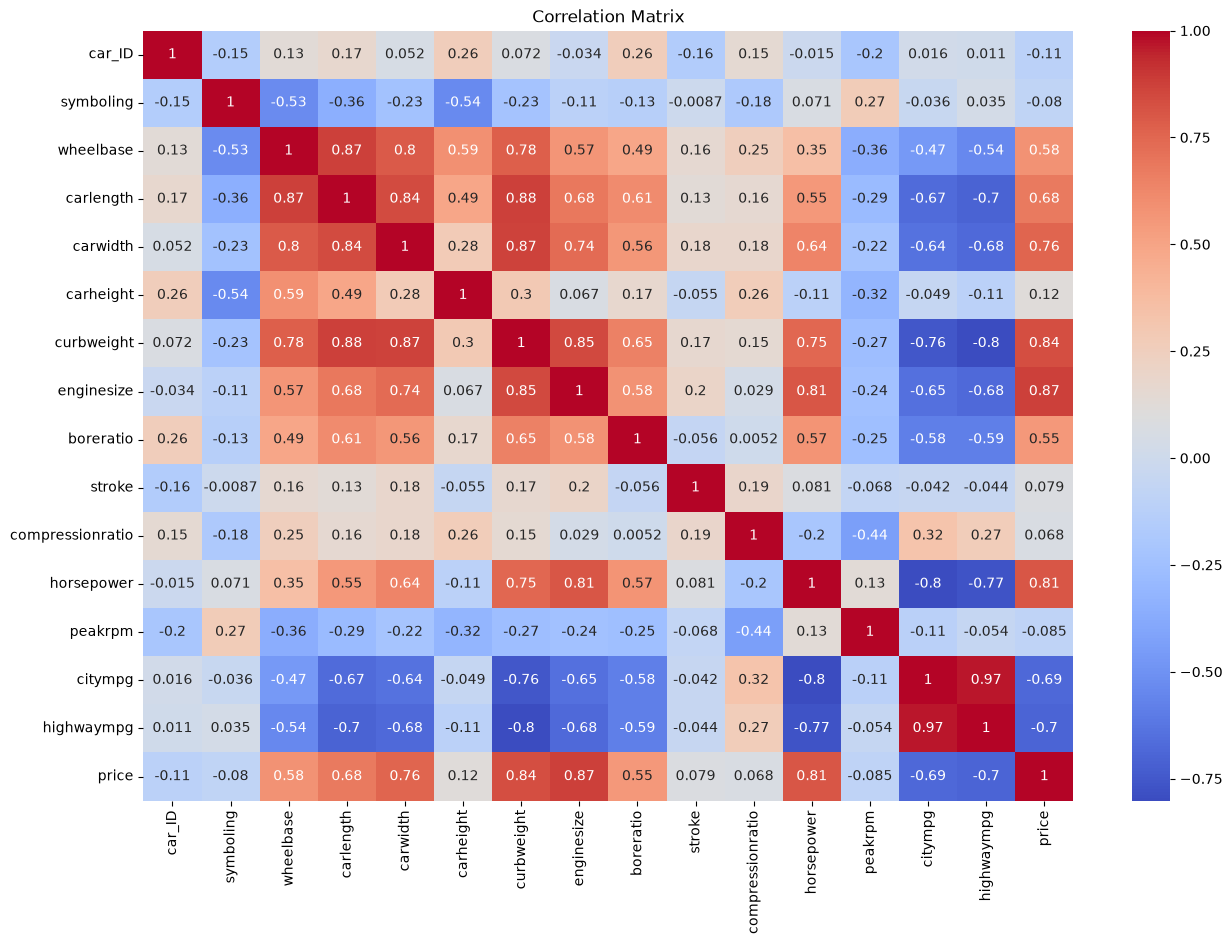

In [8]:
# Data exploration
# Build the Correlation matrix using corr function and produce it into a heatmap
corr = cars.corr(numeric_only=True)
plt.figure(figsize=(15, 10))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

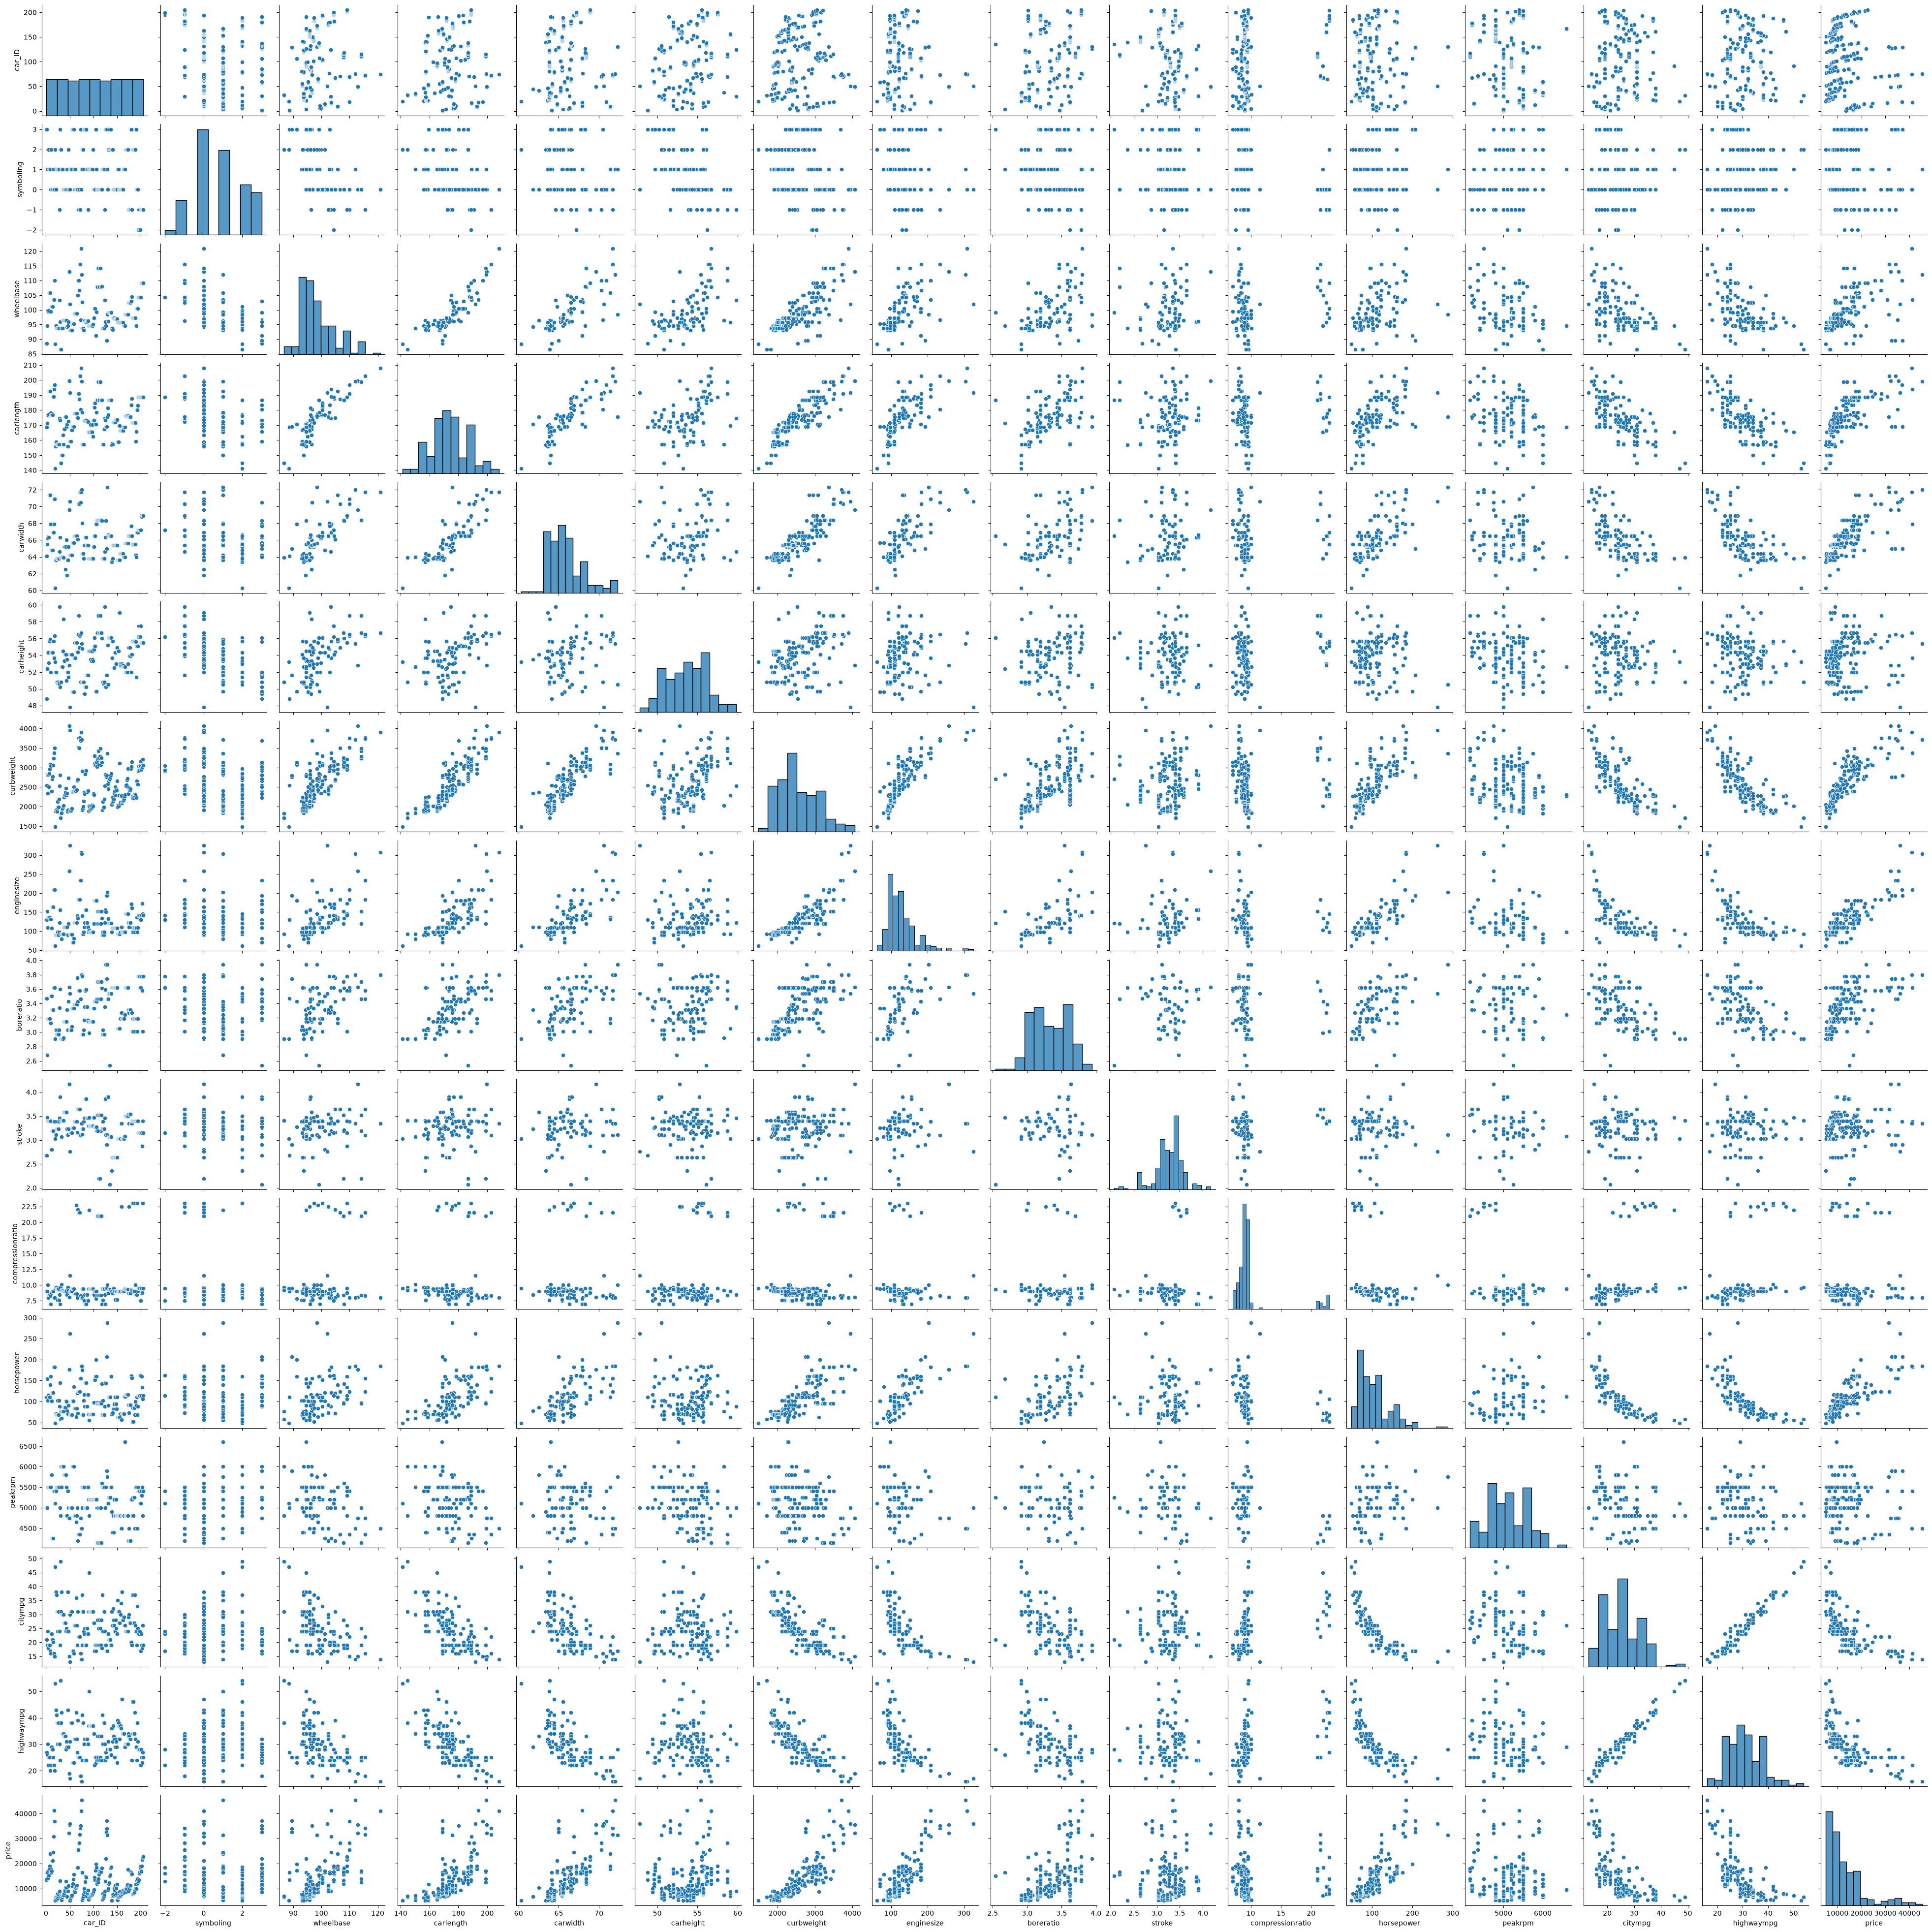

In [9]:
# Perform a Pairplot for cars datasets
sns.pairplot(cars)
plt.show()

In [10]:
# Data cleaning
# Remove irrelevant columns. There should be 3 columns that are not useful for machine learning
cars.drop(['car_ID', 'symboling', 'CarName'], axis=1, inplace=True)

In [11]:
#Add in the 'enginetype','fueltype','aspiration','carbody','cylindernumber','drivewheel','doornumber','enginelocation','fuelsystem' columns to transform into sig_cat_col
#Create dummy variables
sig_cat_col=['enginetype','fueltype','aspiration','carbody','cylindernumber','drivewheel','doornumber','enginelocation','fuelsystem']
dummy_variable=pd.get_dummies(cars[sig_cat_col])

In [12]:
#Concat the transformed columns and drop the original columns
cars=pd.concat([cars,dummy_variable],axis=1)
cars.drop(sig_cat_col,axis=1,inplace=True)

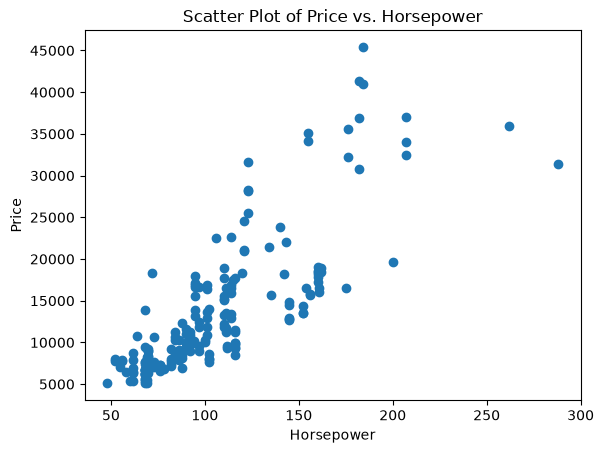

In [13]:
# Scatter plot of price vs. horsepower
plt.scatter(cars['horsepower'], cars['price'])
plt.xlabel('Horsepower')
plt.ylabel('Price')
plt.title('Scatter Plot of Price vs. Horsepower')
plt.show()

In [14]:
# Perform Train-test split. Understand which is variable you want to predict to be used as Y
X = cars.drop('price', axis=1)
y = cars['price']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

In [15]:
# Perform Feature scaling using standard scaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [16]:
# Perform Linear regression
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)
lr_mse = mean_squared_error(y_test, lr_pred)
lr_r2 = r2_score(y_test, lr_pred)

In [17]:
#Print the results
print("Prediction Using Standard Scaling",lr_pred)
print("R2 Score Using Standard Scaling",lr_r2)
print('Mean Squared Error  Using Standard Scaling::', lr_mse)
print('Root Mean Squared Error  Using Standard Scaling::', np.sqrt(lr_mse))

Prediction Using Standard Scaling [ 5940.46000357 19818.60940506 15564.25332518 -1953.59971342
  9739.94226943 12602.23151231  6372.38906328  5807.6798559
 17046.65784532  7506.94471418 20007.36844985 34646.66051989
 12733.60931049 13985.63954437  6784.57924203 12411.54459641
 10053.19006148 19558.3350761   9351.90080811  6596.66900096
  9353.32021679 16521.05406403  9909.98268151 13154.21755227
 21188.46713775  6965.02485277  7682.13913773 16017.28041214
  6996.76912536  5855.487052    9640.12141956 10811.58861274
 17157.13495266  9784.57133247  6229.39165231 29051.761102
 12969.22826053 12402.69810119  5837.60513042 37626.45380832
  6474.46250296]
R2 Score Using Standard Scaling 0.8606736169333002
Mean Squared Error  Using Standard Scaling:: 10786141.181293583
Root Mean Squared Error  Using Standard Scaling:: 3284.226116042192


Classification Models

In [18]:
# Import required libraries
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.datasets import load_breast_cancer
data = load_breast_cancer()

In [19]:
data

{'data': array([[1.799e+01, 1.038e+01, 1.228e+02, ..., 2.654e-01, 4.601e-01,
         1.189e-01],
        [2.057e+01, 1.777e+01, 1.329e+02, ..., 1.860e-01, 2.750e-01,
         8.902e-02],
        [1.969e+01, 2.125e+01, 1.300e+02, ..., 2.430e-01, 3.613e-01,
         8.758e-02],
        ...,
        [1.660e+01, 2.808e+01, 1.083e+02, ..., 1.418e-01, 2.218e-01,
         7.820e-02],
        [2.060e+01, 2.933e+01, 1.401e+02, ..., 2.650e-01, 4.087e-01,
         1.240e-01],
        [7.760e+00, 2.454e+01, 4.792e+01, ..., 0.000e+00, 2.871e-01,
         7.039e-02]], shape=(569, 30)),
 'target': array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
        0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0,
        1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0,
        1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1,
        1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1,

In [20]:
import pandas as pd

In [21]:
# Load the dataset and assign the X data and Y labels
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target)

In [22]:
# Perform the Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0, stratify=y)

# Scale the features (needed for Logistic Regression and KNN, which are scale-sensitive)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [23]:
# Decision tree
dt = DecisionTreeClassifier(random_state=0)
params = {'criterion': ['gini', 'entropy'],
          'max_depth': range(1, 11)}
grid_search = GridSearchCV(estimator=dt, param_grid=params, cv=5)
grid_search.fit(X_train, y_train)
dt_pred = grid_search.predict(X_test)
dt_acc = accuracy_score(y_test, dt_pred)
dt_cm = confusion_matrix(y_test, dt_pred)
dt_cr = classification_report(y_test, dt_pred)
print('Best params:', grid_search.best_params_)

Best params: {'criterion': 'gini', 'max_depth': 4}


In [24]:
# Logistic regression
lr = LogisticRegression(max_iter=5000)
# Only valid penalty/solver combinations are searched ('none' and 'elasticnet' are not
# supported by most solvers, and those combinations would just fail during the search)
params = [{'penalty': ['l1', 'l2'],
           'C': np.logspace(-4, 4, 20),
           'solver': ['liblinear', 'saga']},
          {'penalty': ['l2'],
           'C': np.logspace(-4, 4, 20),
           'solver': ['lbfgs', 'newton-cg', 'sag']}]
grid_search = GridSearchCV(estimator=lr, param_grid=params, cv=5)
grid_search.fit(X_train, y_train)
lr_pred = grid_search.predict(X_test)
lr_acc = accuracy_score(y_test, lr_pred)
lr_cm = confusion_matrix(y_test, lr_pred)
lr_cr = classification_report(y_test, lr_pred)
print('Best params:', grid_search.best_params_)

Best params: {'C': np.float64(0.08858667904100823), 'penalty': 'l2', 'solver': 'liblinear'}


In [25]:
# KNN
knn = KNeighborsClassifier()
params = {'n_neighbors': range(1, 11)}
grid_search = GridSearchCV(estimator=knn, param_grid=params, cv=5)
grid_search.fit(X_train, y_train)
knn_pred = grid_search.predict(X_test)
knn_acc = accuracy_score(y_test, knn_pred)
knn_cm = confusion_matrix(y_test, knn_pred)
knn_cr = classification_report(y_test, knn_pred)
print('Best params:', grid_search.best_params_)

Best params: {'n_neighbors': 8}


In [26]:
# Perform Model evaluation
print('Decision Tree:\n')
print(f'Accuracy: {dt_acc:.4f}\n')
print('Confusion matrix:\n', dt_cm)
print('\nClassification report:\n', dt_cr)

print('\nLogistic Regression:\n')
print(f'Accuracy: {lr_acc:.4f}\n')
print('Confusion matrix:\n', lr_cm)
print('\nClassification report:\n', lr_cr)

print('\nKNN:\n')
print(f'Accuracy: {knn_acc:.4f}\n')
print('Confusion matrix:\n', knn_cm)
print('\nClassification report:\n', knn_cr)

Decision Tree:

Accuracy: 0.9386

Confusion matrix:
 [[40  2]
 [ 5 67]]

Classification report:
               precision    recall  f1-score   support

           0       0.89      0.95      0.92        42
           1       0.97      0.93      0.95        72

    accuracy                           0.94       114
   macro avg       0.93      0.94      0.93       114
weighted avg       0.94      0.94      0.94       114


Logistic Regression:

Accuracy: 0.9737

Confusion matrix:
 [[39  3]
 [ 0 72]]

Classification report:
               precision    recall  f1-score   support

           0       1.00      0.93      0.96        42
           1       0.96      1.00      0.98        72

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114


KNN:

Accuracy: 0.9649

Confusion matrix:
 [[39  3]
 [ 1 71]]

Classification report:
               precision    recall  f1-score   support

  